In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('../data/train.csv', sep=',')
print(f'Shape: {df.shape}')
print(f'Дубликаты: {df.duplicated().sum()}')
print(f'Числовых колонок: {df.select_dtypes(include='number').shape[1]}')
print(f'Категориальных колонок: {df.select_dtypes(include=['object', 'string']).shape[1]}')

Shape: (1460, 81)
Дубликаты: 0
Числовых колонок: 38
Категориальных колонок: 43


Датасет содержит 1460 объектов и 81 признак. Из них 38 числовых и 43 категориальных. Дупликатов нет. Целевая переменная - SalePrice.

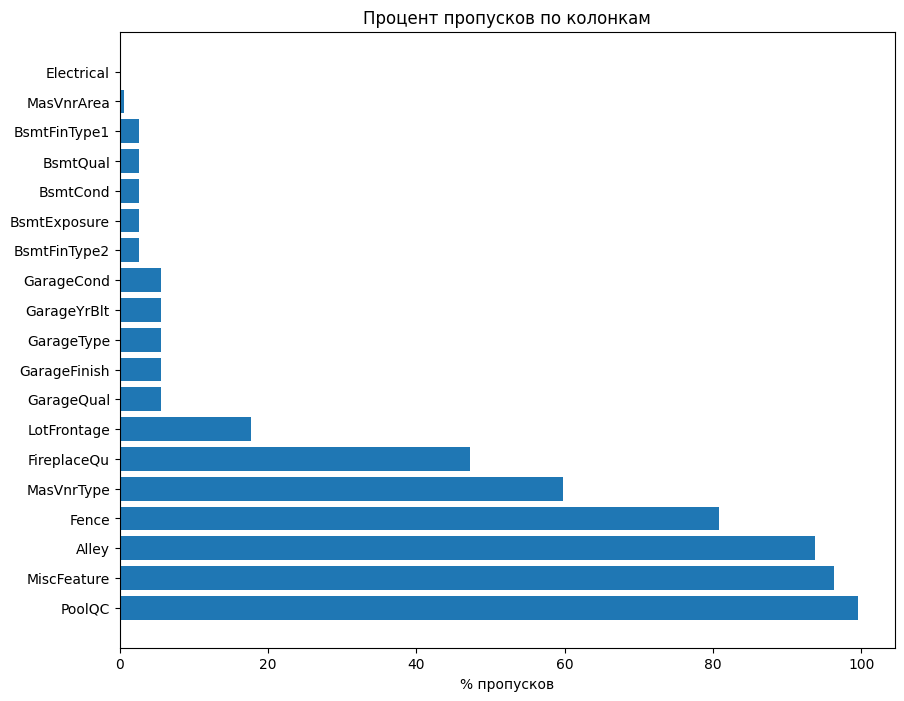

In [51]:
missing = df.isnull().sum()
missing = (missing / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, 8))
plt.barh(missing.index, missing.values)
plt.xlabel('% пропусков')
plt.title('Процент пропусков по колонкам')
plt.show()

19 колонок содержат пропуски. Колонкии с более 50 % пропусков будут удалены.

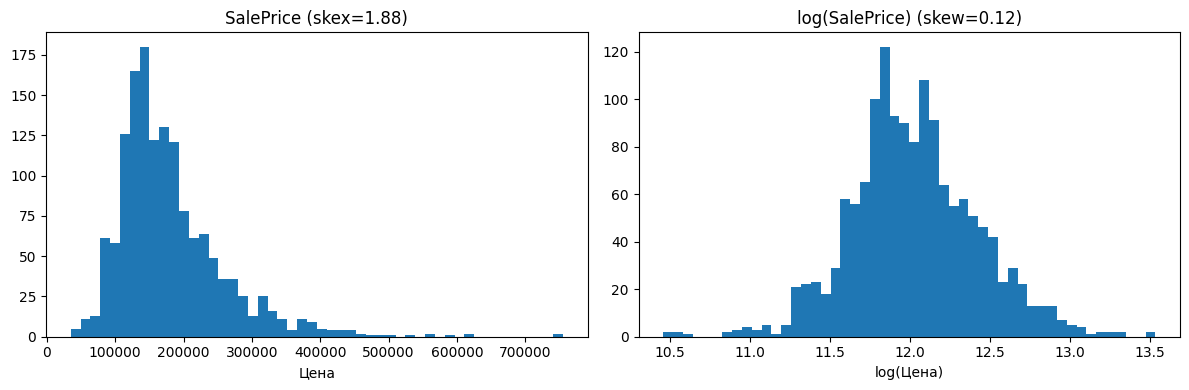

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(df['SalePrice'], bins=50)
axes[0].set_title(f'SalePrice (skex={df['SalePrice'].skew():.2f})')
axes[0].set_xlabel('Цена')

axes[1].hist(np.log1p(df['SalePrice']), bins=50)
axes[1].set_title(f'log(SalePrice) (skew={np.log1p(df["SalePrice"]).skew():.2f})')
axes[1].set_xlabel('log(Цена)')

plt.tight_layout()
plt.show()

SalePrice имеет правостороннюю скошенность (skew), большинство домов дешевые, но есть длинный хвост (справа) дорогих домов. После логарифмирования таргета, снижается skew, распределение становится ближе к нормальному. 

Ошибка начинает измеряться в относительных а не абсолютных величинах. Ошибиться на 10% на доме за $50k так же плохо, как ошибиться в доме за $500k на 10 %.

На этапе предикта применим np.expm1() для обратного преобразования, для получения интерпретируемой величины.

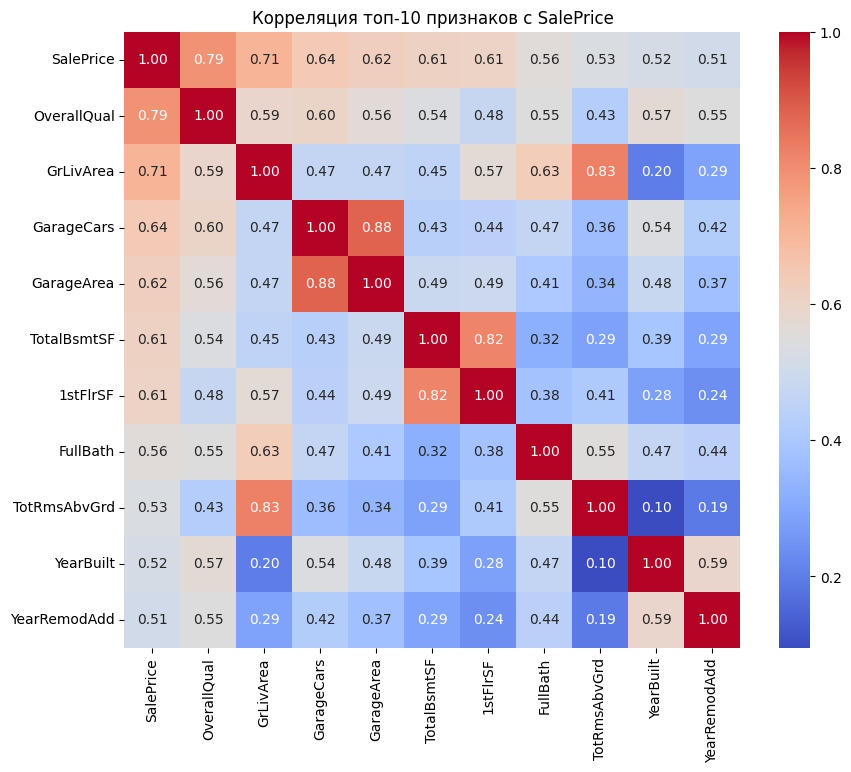

In [59]:
num_cols = df.select_dtypes(include=[np.number])
correlations = num_cols.corr()['SalePrice'].abs().sort_values(ascending=False)
top_feats = correlations.head(11).index

plt.figure(figsize=(10, 8))
sns.heatmap(
  df[top_feats].corr(),
  annot=True,
  fmt='.2f',
  cmap='coolwarm',
  square=True
  )
plt.title('Корреляция топ-10 признаков с SalePrice')
plt.show()


Обнаружена мультиколлинеарность между парами GarageCars/GarageArea (0,88), TotalBsmtSF/1stFlrSF, GrLivArea/TotRmsAbvGrd(0,83). Эти признаки несут дублирующую информацию. Позже рассмотрим удаление одного признака из пары или создание составных фич.

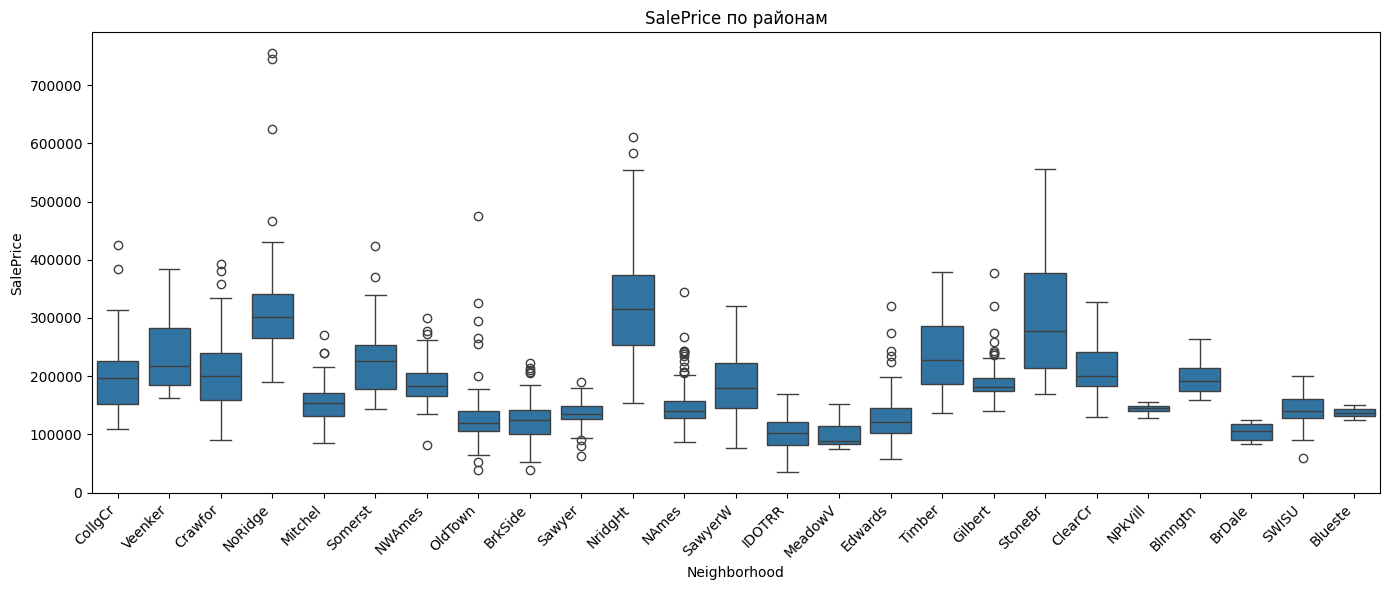

Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
CollgCr    197200.0
Blmngtn    191000.0
NWAmes     182900.0
Gilbert    181000.0
SawyerW    179900.0
Mitchel    153500.0
NPkVill    146000.0
NAmes      140000.0
SWISU      139500.0
Blueste    137500.0
Sawyer     135000.0
BrkSide    124300.0
Edwards    121750.0
OldTown    119000.0
BrDale     106000.0
IDOTRR     103000.0
MeadowV     88000.0
Name: SalePrice, dtype: float64


In [61]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice')
plt.xticks(rotation=45, ha='right')
plt.title('SalePrice по районам')
plt.tight_layout()
plt.show()

print(df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False))

Район - довольно сильный предиктор цены. Зная район, мы будем понимать в каком ценовом диапазоне находится дом. Также есть разбросы внутри районов, что говорит о неоднородности жилья.

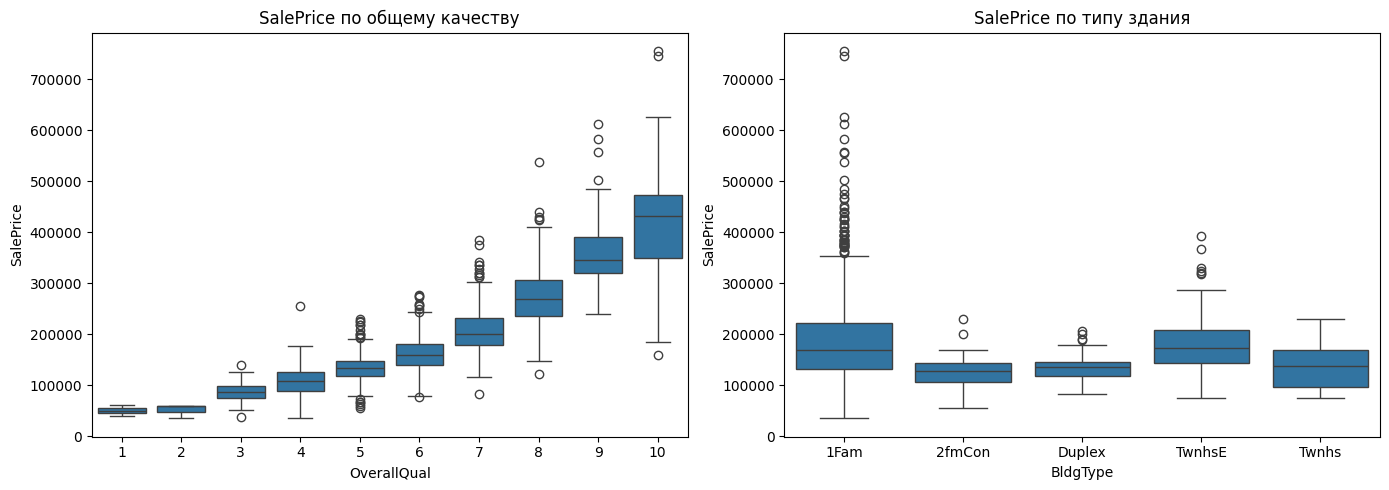

In [62]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(data=df, x='OverallQual', y='SalePrice', ax=axes[0])
axes[0].set_title('SalePrice по общему качеству')

sns.boxplot(data=df, x='BldgType', y='SalePrice', ax=axes[1])
axes[1].set_title('SalePrice по типу здания')

plt.tight_layout()
plt.show()

OverallQual показывает почти монотонную зависимость с SalePrice (corr=0.79). В BldgType 1Fam в медиане дороже примерно на $50k чем  duplex или twnhs.